In [20]:
import torch

import numpy as np
import sys
import os
import torch

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.LoRa import LoRa
from utils.bam import MultiBAMv4, SymbolClassifier

import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)

c:\Users\priba\Sean-2025\INC-LAB\BAM\INC-BAM\utils\my_lora_utils.py


In [ ]:
sf = 9
bw = 125000
fs = 1000000
lora_init = LoRa(sf, bw)
input_row = 512
input_col = 33
second_layer = 1024
third_layer = 64

## HOW TO LOAD WEIGHT
layers = [input_col * input_row, second_layer, third_layer] # <-- must match training

multi_bam = MultiBAMv4(layers_dims=layers, eta=1e-5)

for i, bam in enumerate(multi_bam.bams):
    path = f"weight_{input_row*input_col}_{second_layer}_{third_layer}/weights_layer_{i}.npy"

    if os.path.isfile(path):
        w_np = np.load(path)
        bam.W = torch.tensor(w_np, dtype=torch.float32, device=bam.device)
        print(f"✅ Loaded layer {i} | shape {bam.W.shape}")
    else:
        print(f"⚠️ Missing file for layer {i}: {path}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_layers = [third_layer, 1024,512, int(2**sf)]
model = SymbolClassifier(class_layers).to(device)
model.load_state_dict(torch.load("symbol_classifier.pt", map_location=device))

model.eval()   # 🔴 VERY IMPORTANT
    

✅ Loaded layer 0 | shape torch.Size([1024, 16896])
✅ Loaded layer 1 | shape torch.Size([64, 1024])


RuntimeError: Error(s) in loading state_dict for SymbolClassifier:
	Missing key(s) in state_dict: "net.4.weight", "net.4.bias". 
	size mismatch for net.0.weight: copying a param with shape torch.Size([256, 64]) from checkpoint, the shape in current model is torch.Size([1024, 64]).
	size mismatch for net.0.bias: copying a param with shape torch.Size([256]) from checkpoint, the shape in current model is torch.Size([1024]).
	size mismatch for net.2.weight: copying a param with shape torch.Size([512, 256]) from checkpoint, the shape in current model is torch.Size([512, 1024]).

seed :  625
(1, 64)
desired symbol : 400
Predicted symbol: 399
(512, 33)


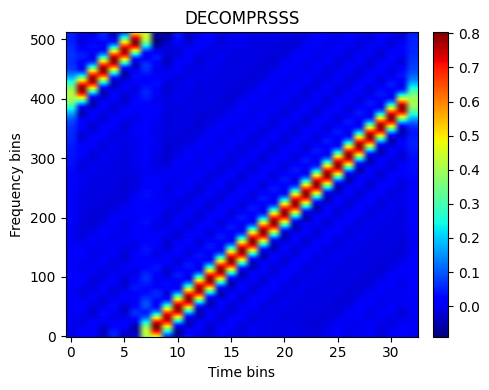

In [ ]:
symbol1 = 400
# EXAMPLE OF COMPRESS and DECOMPRESS
random_ = np.random.randint(1, 999)  # integer from 1 to 10 (inclusive)
print("seed : ",random_)
seed = random_
x1 = lora_init.gen_symbol_fs(symbol1, sf=sf, bw=bw, Fs=fs)  # you had Fs=int(bw*8)=1e6

snr = -5
x = lora_init.awgn_iq_with_seed(x1,snr,seed)

input_spec = create_spectrogram_from_torch(x,sf,bw,fs,input_row,input_col,0,0,1,None)
#### STEP 3 FLATTEN INPUT ########
flat = input_spec.flatten().reshape(1, -1) # BEFORE COMPRESS MUST 

out1 = multi_bam.compress(flat)
print(out1.shape)
a = out1.squeeze() 

x = torch.tensor(a, dtype=torch.float32).unsqueeze(0).to(device)
x = x / (torch.norm(x) + 1e-8)  
 
with torch.no_grad():
    logits = model(x)
    pred = torch.argmax(logits, dim=1)
print("desired symbol :",symbol1)
print("Predicted symbol:", pred.item())

out2 = multi_bam.decompress(out1)

#### STEP 4 AFTER DECOMPRESS RESHAPE to INITIAL SHAPE ########
reco_flat = out2.reshape(-1)  # AFTER DECOMPRESS MUST
reco_spec = reco_flat.reshape(input_row, input_col)
print(reco_spec.shape)

array_a = [reco_spec]

show_multiple_spectrograms(array_a,["DECOMPRSSS"],1)